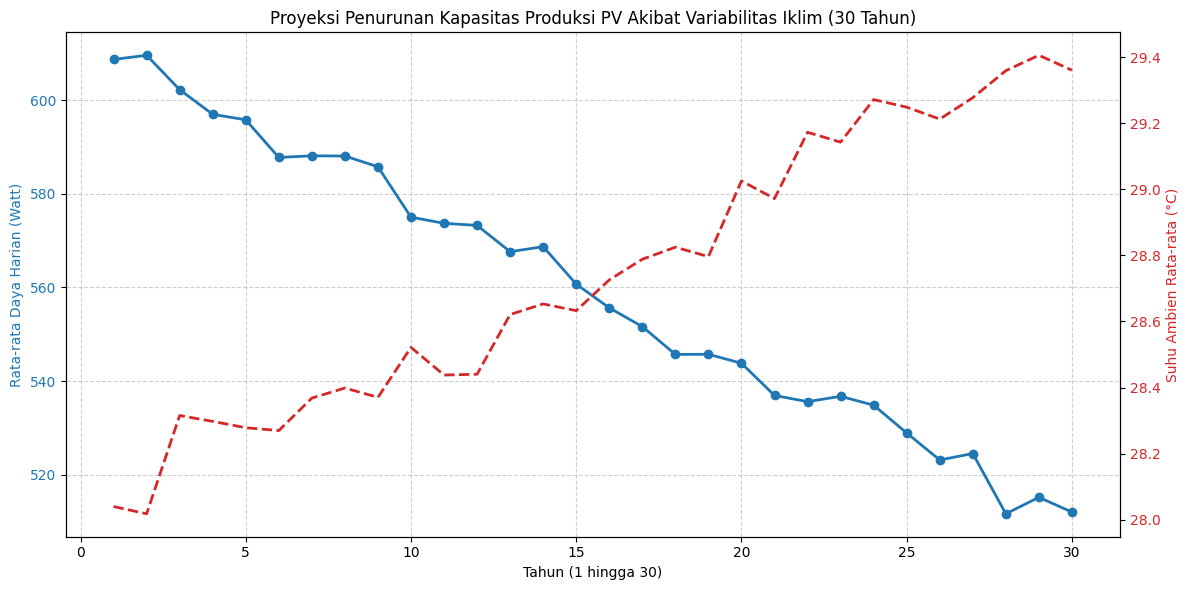

Produksi rata-rata Tahun ke-1 : 608.73 Watt
Produksi rata-rata Tahun ke-30: 511.99 Watt
Total Penurunan Kapasitas     : 15.89 %


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. PARAMETER SISTEM PV & IKLIM
# ==========================================
P_STC = 1000        # Kapasitas PV terpasang (Watt)
G_STC = 1000        # Radiasi standar (W/m^2)
T_STC = 25          # Suhu standar (Celcius)
gamma = -0.004      # Koefisien suhu daya (-0.4% / C)
NOCT = 45           # Nominal Operating Cell Temp (Celcius)
deg_rate = 0.005    # Degradasi fisik panel (0.5% per tahun)

years = 30
days_per_year = 365
total_days = years * days_per_year
time_days = np.arange(total_days)

# ==========================================
# 2. PEMBUATAN DATA SINTETIS (PROYEKSI IKLIM)
# ==========================================
np.random.seed(42) # Untuk reproduksibilitas

# A. Tren Peningkatan Suhu (Naik ~1.5 C dalam 30 tahun)
# Suhu dasar rata-rata harian 28 C dengan fluktuasi musiman (sinusoidal) dan noise
temp_trend = np.linspace(0, 1.5, total_days)
temp_seasonal = 2 * np.sin(2 * np.pi * time_days / days_per_year)
temp_noise = np.random.normal(0, 1.5, total_days)
T_amb = 28 + temp_trend + temp_seasonal + temp_noise

# B. Tren Radiasi dan Tutupan Awan (GHI)
# Rata-rata puncak harian 800 W/m2, fluktuasi musiman, tren menurun 2% akibat awan
rad_trend = np.linspace(1, 0.98, total_days)
rad_seasonal = 100 * np.cos(2 * np.pi * time_days / days_per_year)
G_clear = (800 + rad_seasonal) * rad_trend
cloud_factor = np.random.uniform(0.7, 1.0, total_days) # Langit cerah hingga agak berawan
G_actual = G_clear * cloud_factor

# C. Kejadian Cuaca Ekstrem (Kabut Asap / Haze)
# Frekuensi meningkat seiring waktu. Saat terjadi, radiasi drop 20-40%
haze_prob = np.linspace(0.01, 0.05, total_days) # Probabilitas Karhutla naik dari 1% ke 5%
haze_events = np.random.binomial(1, haze_prob)
haze_penalty = np.random.uniform(0.6, 0.8, total_days) # Sisa radiasi saat kabut asap
G_actual = np.where(haze_events == 1, G_actual * haze_penalty, G_actual)

# ==========================================
# 3. PERHITUNGAN KINERJA PV
# ==========================================
# Suhu Sel (T_cell)
T_cell = T_amb + ((NOCT - 20) / 800) * G_actual

# Faktor Kerugian Suhu (L_temp)
L_temp = 1 + gamma * (T_cell - T_STC)

# Faktor Degradasi Jangka Panjang
years_array = time_days / days_per_year
L_deg = (1 - deg_rate) ** years_array

# Total Daya Output Harian (asumsi 1 titik waktu mewakili agregat harian)
P_out = P_STC * (G_actual / G_STC) * L_temp * L_deg

# Mengubah ke DataFrame untuk analisis tahunan
df = pd.DataFrame({
    'Day': time_days,
    'Year': (time_days // days_per_year) + 1,
    'T_amb': T_amb,
    'G_actual': G_actual,
    'P_out': P_out
})

# Agregasi Rata-rata Tahunan
yearly_data = df.groupby('Year').agg({
    'P_out': 'mean',
    'T_amb': 'mean',
    'G_actual': 'mean'
}).reset_index()

# ==========================================
# 4. VISUALISASI HASIL PEMODELAN
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Daya Output (Sumbu Kiri)
color = 'tab:blue'
ax1.set_xlabel('Tahun (1 hingga 30)')
ax1.set_ylabel('Rata-rata Daya Harian (Watt)', color=color)
ax1.plot(yearly_data['Year'], yearly_data['P_out'], color=color, marker='o', linewidth=2, label='Daya Output (P_out)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Suhu Rata-rata (Sumbu Kanan)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Suhu Ambien Rata-rata (°C)', color=color)  
ax2.plot(yearly_data['Year'], yearly_data['T_amb'], color=color, linestyle='--', linewidth=2, label='Suhu Ambien')
ax2.tick_params(axis='y', labelcolor=color)

# Anotasi Kesimpulan
plt.title("Proyeksi Penurunan Kapasitas Produksi PV Akibat Variabilitas Iklim (30 Tahun)")
fig.tight_layout()  
plt.show()

# Print Metrik Evaluasi
print(f"Produksi rata-rata Tahun ke-1 : {yearly_data['P_out'].iloc[0]:.2f} Watt")
print(f"Produksi rata-rata Tahun ke-30: {yearly_data['P_out'].iloc[-1]:.2f} Watt")
print(f"Total Penurunan Kapasitas     : {((yearly_data['P_out'].iloc[0] - yearly_data['P_out'].iloc[-1]) / yearly_data['P_out'].iloc[0]) * 100:.2f} %")